In [1]:
# Cell 1 — Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cell 2 — Load Dataset

file_path = r"C:\Users\bts\OneDrive\Desktop\SaiKet Systems\dataset\Telco_Customer_Churn_Dataset.csv"

df = pd.read_csv(file_path)

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Cell 3 — Dataset Shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [4]:
# Cell 4 — Column Names

print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [5]:
# Cell 5 — Data Types

df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [6]:
# Cell 6 — Missing Values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Cell 7 — Duplicate Records

print("Number of duplicate records:", df.duplicated().sum())

Number of duplicate records: 0


In [8]:
# Cell 8 — Descriptive Statistics

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Cell 9 — Relevant Columns

relevant_columns = [
    "customerID",
    "tenure",
    "MonthlyCharges",
    "Contract",
    "Churn"
]

df[relevant_columns].head()

,customerID,tenure,MonthlyCharges,Contract,Churn
0,7590-VHVEG,1,29.85,Month-to-month,No
1,5575-GNVDE,34,56.95,One year,No
2,3668-QPYBK,2,53.85,Month-to-month,Yes
3,7795-CFOCW,45,42.30,One year,No
4,9237-HQITU,2,70.70,Month-to-month,Yes


In [10]:
# Cell 10 — Unique Values

print("Contract values:")
print(df["Contract"].unique())

print("\nChurn values:")
print(df["Churn"].unique())

Contract values:
<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

Churn values:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [11]:
# Cell 11 — Convert TotalCharges to Numeric

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Invalid TotalCharges values:", df["TotalCharges"].isnull().sum())

Invalid TotalCharges values: 11


In [12]:
# Cell 12 — Handle Invalid Values

df = df.dropna(subset=["TotalCharges"]).copy()

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (7032, 21)


In [13]:
# Cell 13 — Verify Cleaned Dataset

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate records:")
print(df.duplicated().sum())

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate records:
0


In [14]:
# Cell 14 — Overall Churn Summary

total_customers = len(df)

churned_customers = (
    df["Churn"] == "Yes"
).sum()

overall_churn_rate = (
    churned_customers / total_customers
) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Overall Churn Rate: {:.2f}%".format(overall_churn_rate))

Total Customers: 7032
Churned Customers: 1869
Overall Churn Rate: 26.58%


In [15]:
# Cell 15 — Create Tenure Segments

tenure_bins = [-1, 12, 24, 48, 60, np.inf]

tenure_labels = [
    "New Customers",
    "Early Customers",
    "Mid-term Customers",
    "Long-term Customers",
    "Loyal Customers"
]

df["TenureSegment"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels
)

df["TenureSegment"].value_counts().sort_index()

TenureSegment
New Customers          2175
Early Customers        1024
Mid-term Customers     1594
Long-term Customers     832
Loyal Customers        1407
Name: count, dtype: int64

In [16]:
# Cell 16 — Tenure Segment Analysis

tenure_analysis = df.groupby(
    "TenureSegment",
    observed=False
).agg(
    Customers=("customerID", "count"),
    Churned_Customers=(
        "Churn",
        lambda x: (x == "Yes").sum()
    )
)

tenure_analysis["Percentage_of_Total"] = (
    tenure_analysis["Customers"] /
    len(df) * 100
)

tenure_analysis["Churn_Rate"] = (
    tenure_analysis["Churned_Customers"] /
    tenure_analysis["Customers"] * 100
)

tenure_analysis.round(2)

,Customers,Churned_Customers,Percentage_of_Total,Churn_Rate
TenureSegment,,,,
New Customers,2175,1037,30.93,47.68
Early Customers,1024,294,14.56,28.71
Mid-term Customers,1594,325,22.67,20.39
Long-term Customers,832,120,11.83,14.42
Loyal Customers,1407,93,20.01,6.61


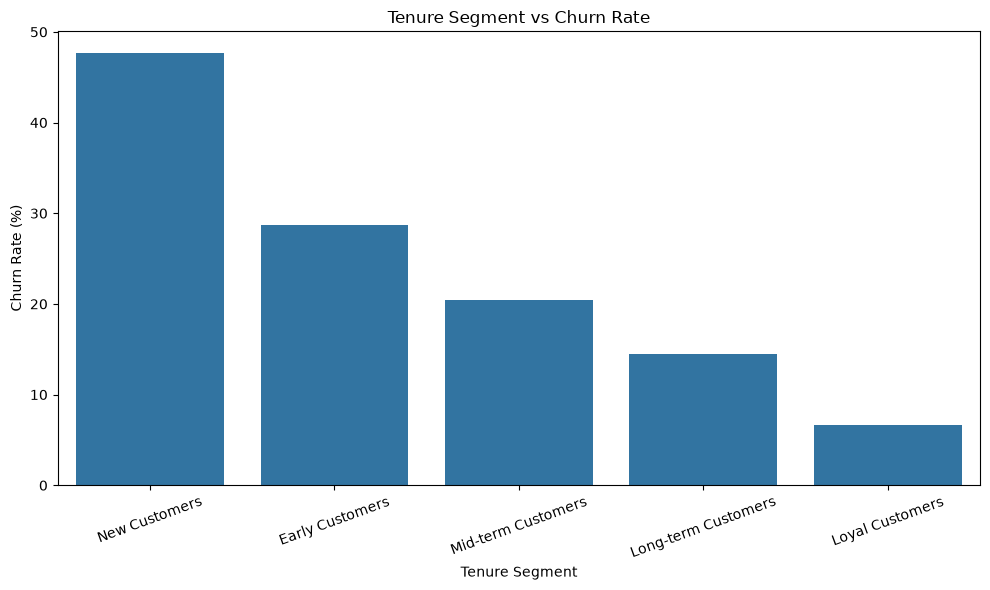

In [17]:
# Cell 17 — Tenure Segment vs Churn Rate

plt.figure(figsize=(10, 6))

sns.barplot(
    data=tenure_analysis.reset_index(),
    x="TenureSegment",
    y="Churn_Rate"
)

plt.title("Tenure Segment vs Churn Rate")
plt.xlabel("Tenure Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [18]:
# Cell 18 — Tenure Findings

highest_tenure_churn = tenure_analysis["Churn_Rate"].idxmax()
lowest_tenure_churn = tenure_analysis["Churn_Rate"].idxmin()

print(
    "Highest churn tenure segment:",
    highest_tenure_churn
)

print(
    "Churn rate:",
    round(
        tenure_analysis.loc[
            highest_tenure_churn,
            "Churn_Rate"
        ],
        2
    ),
    "%"
)

print(
    "\nLowest churn tenure segment:",
    lowest_tenure_churn
)

print(
    "Churn rate:",
    round(
        tenure_analysis.loc[
            lowest_tenure_churn,
            "Churn_Rate"
        ],
        2
    ),
    "%"
)

Highest churn tenure segment: New Customers
Churn rate: 47.68 %

Lowest churn tenure segment: Loyal Customers
Churn rate: 6.61 %


In [19]:
# Cell 19 — Monthly Charges Distribution

df["MonthlyCharges"].describe()

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64

In [20]:
# Cell 20 — Create Monthly Charges Segments

charge_bins = [
    df["MonthlyCharges"].min() - 0.01,
    df["MonthlyCharges"].quantile(0.33),
    df["MonthlyCharges"].quantile(0.66),
    df["MonthlyCharges"].max()
]

charge_labels = [
    "Low Charges",
    "Medium Charges",
    "High Charges"
]

df["MonthlyChargeSegment"] = pd.cut(
    df["MonthlyCharges"],
    bins=charge_bins,
    labels=charge_labels,
    include_lowest=True
)

df["MonthlyChargeSegment"].value_counts().sort_index()

MonthlyChargeSegment
Low Charges       2321
Medium Charges    2323
High Charges      2388
Name: count, dtype: int64

In [21]:
# Cell 21 — Monthly Charges Segment Analysis

charge_analysis = df.groupby(
    "MonthlyChargeSegment",
    observed=False
).agg(
    Customers=("customerID", "count"),
    Average_Monthly_Charge=(
        "MonthlyCharges",
        "mean"
    ),
    Churned_Customers=(
        "Churn",
        lambda x: (x == "Yes").sum()
    )
)

charge_analysis["Churn_Rate"] = (
    charge_analysis["Churned_Customers"] /
    charge_analysis["Customers"] * 100
)

charge_analysis.round(2)

,Customers,Average_Monthly_Charge,Churned_Customers,Churn_Rate
MonthlyChargeSegment,,,,
Low Charges,2321,27.77,367,15.81
Medium Charges,2323,68.59,684,29.44
High Charges,2388,97.09,818,34.25


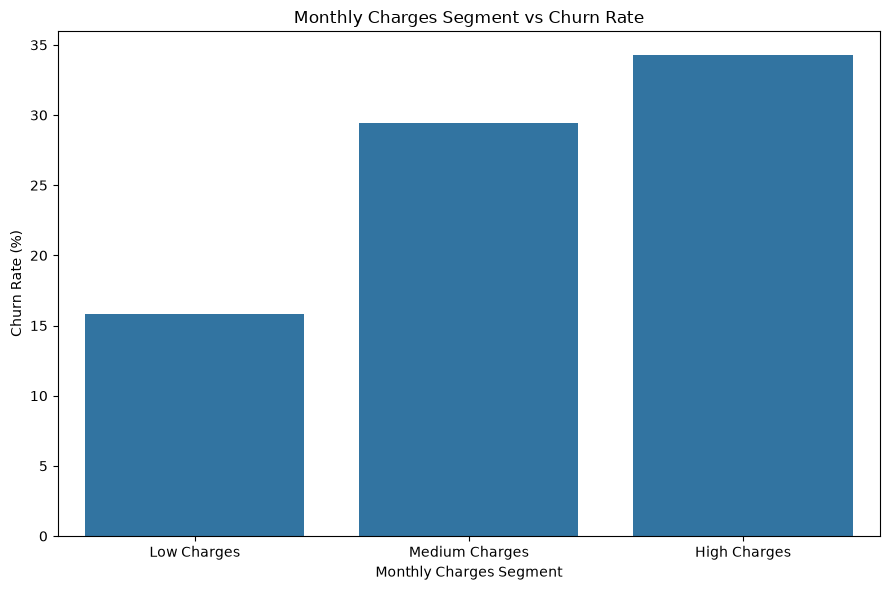

In [22]:
# Cell 22 — Monthly Charges Segment vs Churn Rate

plt.figure(figsize=(9, 6))

sns.barplot(
    data=charge_analysis.reset_index(),
    x="MonthlyChargeSegment",
    y="Churn_Rate"
)

plt.title("Monthly Charges Segment vs Churn Rate")
plt.xlabel("Monthly Charges Segment")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

In [23]:
# Cell 23 — Monthly Charges Findings

highest_charge_churn = charge_analysis["Churn_Rate"].idxmax()

print(
    "Monthly-charge segment with highest churn:",
    highest_charge_churn
)

print(
    "Churn rate:",
    round(
        charge_analysis.loc[
            highest_charge_churn,
            "Churn_Rate"
        ],
        2
    ),
    "%"
)

Monthly-charge segment with highest churn: High Charges
Churn rate: 34.25 %


In [24]:
# Cell 24 — Contract Type Analysis

contract_analysis = df.groupby("Contract").agg(
    Customers=("customerID", "count"),
    Average_Tenure=("tenure", "mean"),
    Average_Monthly_Charges=(
        "MonthlyCharges",
        "mean"
    ),
    Churned_Customers=(
        "Churn",
        lambda x: (x == "Yes").sum()
    )
)

contract_analysis["Churn_Rate"] = (
    contract_analysis["Churned_Customers"] /
    contract_analysis["Customers"] * 100
)

contract_analysis.round(2)

,Customers,Average_Tenure,Average_Monthly_Charges,Churned_Customers,Churn_Rate
Contract,,,,,
Month-to-month,3875,18.04,66.40,1655,42.71
One year,1472,42.07,65.08,166,11.28
Two year,1685,57.07,60.87,48,2.85


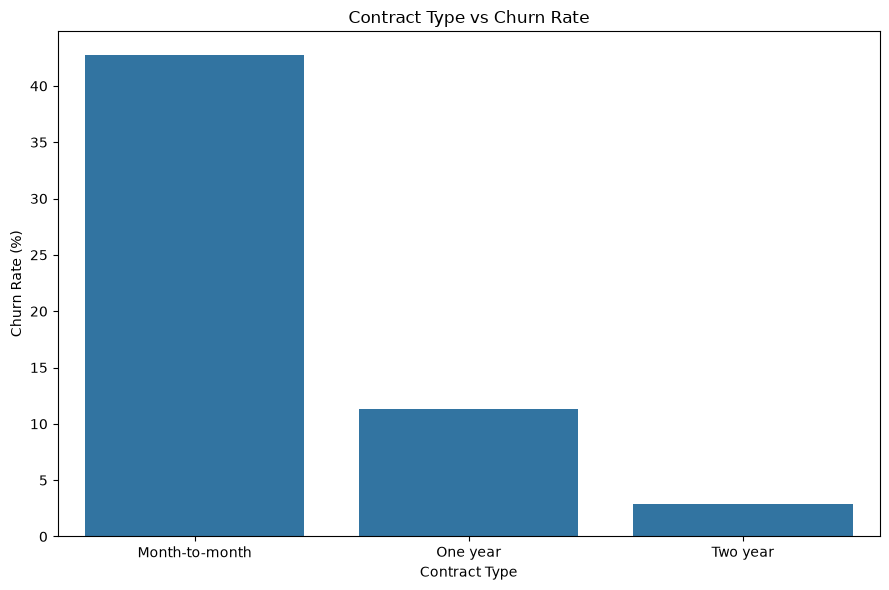

In [25]:
# Cell 25 — Contract Type vs Churn Rate

plt.figure(figsize=(9, 6))

sns.barplot(
    data=contract_analysis.reset_index(),
    x="Contract",
    y="Churn_Rate"
)

plt.title("Contract Type vs Churn Rate")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

In [26]:
# Cell 26 — Contract Findings

highest_contract_churn = contract_analysis["Churn_Rate"].idxmax()
lowest_contract_churn = contract_analysis["Churn_Rate"].idxmin()

print(
    "Highest churn contract:",
    highest_contract_churn
)

print(
    "Churn rate:",
    round(
        contract_analysis.loc[
            highest_contract_churn,
            "Churn_Rate"
        ],
        2
    ),
    "%"
)

print(
    "\nLowest churn contract:",
    lowest_contract_churn
)

print(
    "Churn rate:",
    round(
        contract_analysis.loc[
            lowest_contract_churn,
            "Churn_Rate"
        ],
        2
    ),
    "%"
)

Highest churn contract: Month-to-month
Churn rate: 42.71 %

Lowest churn contract: Two year
Churn rate: 2.85 %


In [27]:
# Cell 27 — Create Combined Customer Segments

tenure_median = df["tenure"].median()
charge_median = df["MonthlyCharges"].median()

df["TenureValue"] = np.where(
    df["tenure"] <= tenure_median,
    "Short Tenure",
    "Long Tenure"
)

df["ChargeValue"] = np.where(
    df["MonthlyCharges"] <= charge_median,
    "Low Value",
    "High Value"
)

df["CustomerSegment"] = (
    df["TenureValue"] +
    " + " +
    df["ChargeValue"]
)

df["CustomerSegment"].value_counts()

CustomerSegment
Short Tenure + Low Value     2085
Long Tenure + High Value     2040
Short Tenure + High Value    1473
Long Tenure + Low Value      1434
Name: count, dtype: int64

In [28]:
# Cell 28 — Combined Customer Segment Analysis

combined_analysis = df.groupby(
    "CustomerSegment"
).agg(
    Customers=("customerID", "count"),
    Average_Tenure=("tenure", "mean"),
    Average_Monthly_Charges=(
        "MonthlyCharges",
        "mean"
    ),
    Churned_Customers=(
        "Churn",
        lambda x: (x == "Yes").sum()
    )
)

combined_analysis["Percentage_of_Total"] = (
    combined_analysis["Customers"] /
    len(df) * 100
)

combined_analysis["Churn_Rate"] = (
    combined_analysis["Churned_Customers"] /
    combined_analysis["Customers"] * 100
)

combined_analysis.round(2)

,Customers,Average_Tenure,Average_Monthly_Charges,Churned_Customers,Percentage_of_Total,Churn_Rate
CustomerSegment,,,,,,
Long Tenure + High Value,2040,55.50,94.29,381,29.01,18.68
Long Tenure + Low Value,1434,52.99,38.92,79,20.39,5.51
Short Tenure + High Value,1473,11.93,85.56,856,20.95,58.11
Short Tenure + Low Value,2085,10.18,39.07,553,29.65,26.52


In [29]:
# Cell 29 — Contract Distribution by Combined Segment

contract_distribution = pd.crosstab(
    df["CustomerSegment"],
    df["Contract"]
)

contract_distribution

Contract,Month-to-month,One year,Two year
CustomerSegment,,,
Long Tenure + High Value,673,621,746
Long Tenure + Low Value,250,423,761
Short Tenure + High Value,1370,87,16
Short Tenure + Low Value,1582,341,162


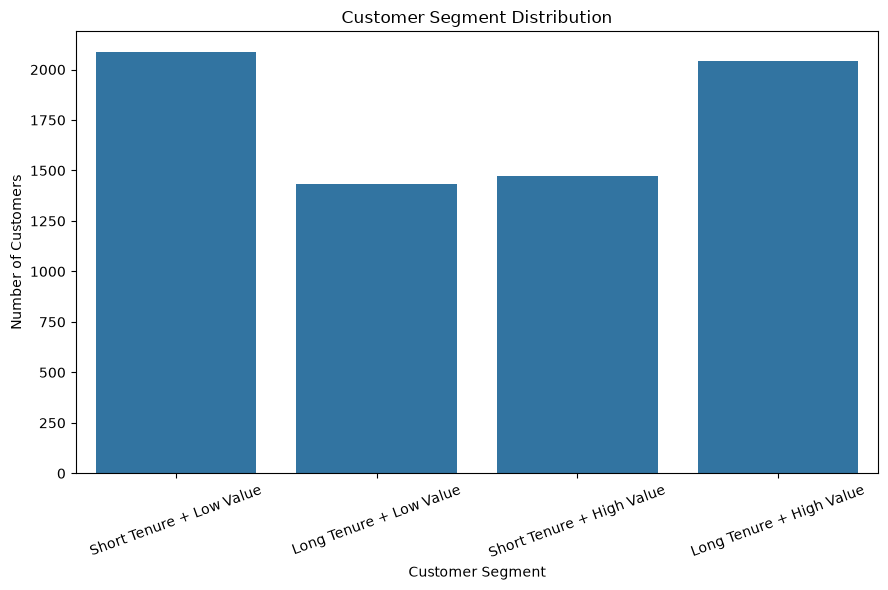

In [30]:
# Cell 30 — Customer Segment Distribution

plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="CustomerSegment"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

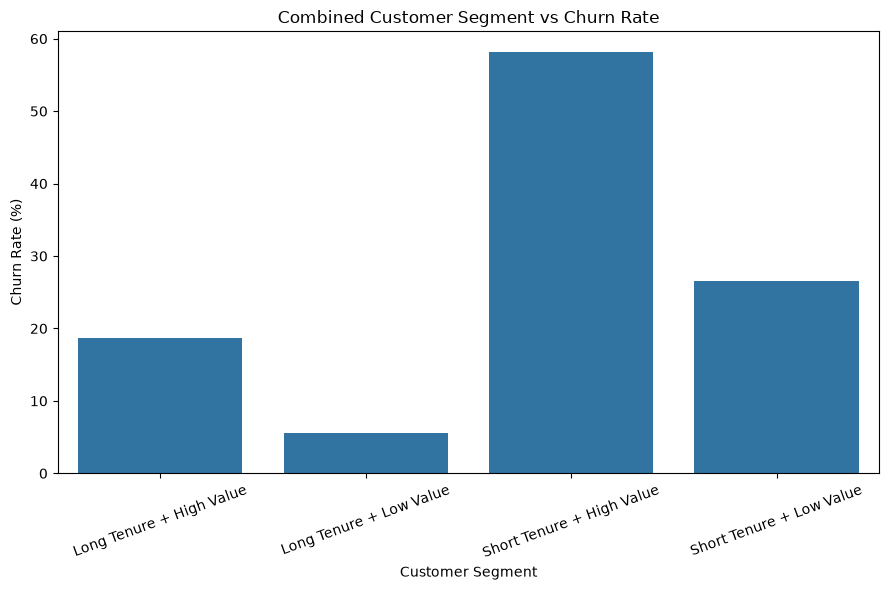

In [31]:
# Cell 31 — Combined Customer Segment vs Churn Rate

plt.figure(figsize=(9, 6))

sns.barplot(
    data=combined_analysis.reset_index(),
    x="CustomerSegment",
    y="Churn_Rate"
)

plt.title("Combined Customer Segment vs Churn Rate")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [32]:
# Cell 32 — Define High-Value Customer Threshold

high_value_threshold = (
    df["MonthlyCharges"].quantile(0.75)
)

print(
    "High-value customer threshold:",
    round(high_value_threshold, 2)
)

High-value customer threshold: 89.86


In [33]:
# Cell 33 — Identify High-Value Customers

df["HighValue"] = np.where(
    df["MonthlyCharges"] >= high_value_threshold,
    "High-Value",
    "Non-High-Value"
)

df["HighValue"].value_counts()

HighValue
Non-High-Value    5274
High-Value        1758
Name: count, dtype: int64

In [34]:
# Cell 34 — High-Value Customer Analysis

high_value_analysis = df.groupby(
    "HighValue"
).agg(
    Customers=("customerID", "count"),
    Average_Monthly_Charges=(
        "MonthlyCharges",
        "mean"
    ),
    Average_Tenure=("tenure", "mean"),
    Churned_Customers=(
        "Churn",
        lambda x: (x == "Yes").sum()
    )
)

high_value_analysis["Churn_Rate"] = (
    high_value_analysis["Churned_Customers"] /
    high_value_analysis["Customers"] * 100
)

high_value_analysis.round(2)

,Customers,Average_Monthly_Charges,Average_Tenure,Churned_Customers,Churn_Rate
HighValue,,,,,
High-Value,1758,100.90,44.74,578,32.88
Non-High-Value,5274,52.76,28.31,1291,24.48


In [35]:
# Cell 35 — High-Value Customer Contract Distribution

high_value_contract_distribution = pd.crosstab(
    df["HighValue"],
    df["Contract"]
)

high_value_contract_distribution

Contract,Month-to-month,One year,Two year
HighValue,,,
High-Value,870,446,442
Non-High-Value,3005,1026,1243


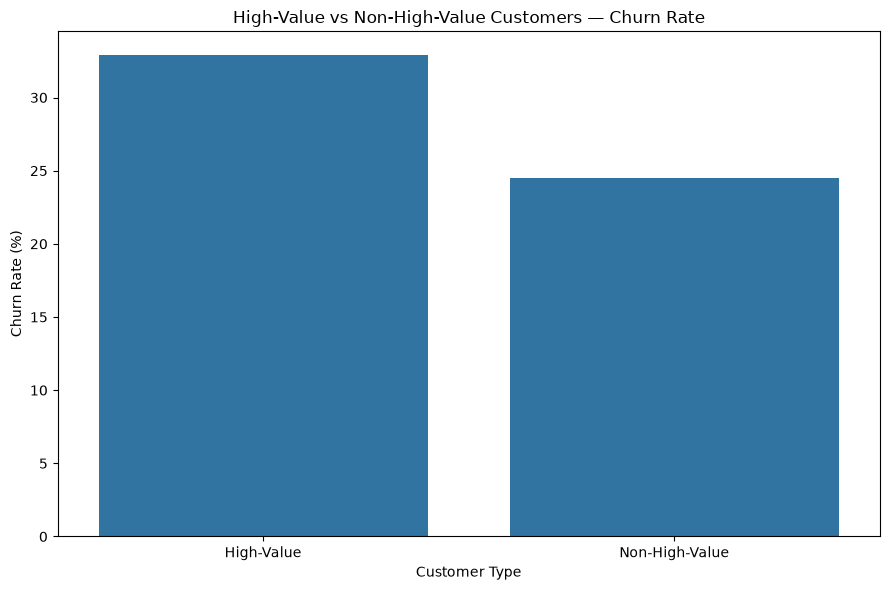

In [36]:
# Cell 36 — High-Value vs Non-High-Value Churn Rate

plt.figure(figsize=(9, 6))

sns.barplot(
    data=high_value_analysis.reset_index(),
    x="HighValue",
    y="Churn_Rate"
)

plt.title("High-Value vs Non-High-Value Customers — Churn Rate")
plt.xlabel("Customer Type")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

In [37]:
# Cell 37 — Already Churned High-Value Customers

high_value_churned = df[
    (df["HighValue"] == "High-Value") &
    (df["Churn"] == "Yes")
].copy()

print(
    "High-value customers who already churned:",
    len(high_value_churned)
)

High-value customers who already churned: 578


In [38]:
# Cell 38 — Active High-Value Customers Showing Risk Characteristics

short_tenure_threshold = (
    df["tenure"].quantile(0.25)
)

active_high_value_at_risk = df[
    (df["HighValue"] == "High-Value") &
    (df["Churn"] == "No") &
    (df["tenure"] <= short_tenure_threshold) &
    (df["Contract"] == "Month-to-month")
].copy()

print(
    "Short-tenure threshold:",
    round(short_tenure_threshold, 2),
    "months"
)

print(
    "Active high-value customers showing risk characteristics:",
    len(active_high_value_at_risk)
)

Short-tenure threshold: 9.0 months
Active high-value customers showing risk characteristics: 41


In [39]:
# Cell 39 — High-Value At-Risk Customer Table

at_risk_columns = [
    "customerID",
    "tenure",
    "MonthlyCharges",
    "Contract",
    "Churn"
]

high_value_at_risk_table = (
    active_high_value_at_risk[
        at_risk_columns
    ]
    .sort_values(
        by="MonthlyCharges",
        ascending=False
    )
)

high_value_at_risk_table.head(20)

,customerID,tenure,MonthlyCharges,Contract,Churn
678,5760-IFJOZ,3,107.95,Month-to-month,No
1719,2081-VEYEH,3,107.95,Month-to-month,No
2387,6734-GMPVK,5,105.30,Month-to-month,No
3872,2018-PZKMU,9,103.10,Month-to-month,No
6963,9547-ITEFG,9,102.60,Month-to-month,No
5031,8118-TJAFG,9,101.50,Month-to-month,No
3270,4132-KALRO,4,100.85,Month-to-month,No
2530,0722-SVSFK,7,100.40,Month-to-month,No
4952,7379-FNIUJ,2,100.20,Month-to-month,No
2280,2754-SDJRD,8,100.15,Month-to-month,No


In [40]:
# Cell 40 — High-Value At-Risk Summary

risk_count = len(
    active_high_value_at_risk
)

risk_avg_monthly_charge = (
    active_high_value_at_risk[
        "MonthlyCharges"
    ].mean()
)

risk_avg_tenure = (
    active_high_value_at_risk[
        "tenure"
    ].mean()
)

print(
    "Total active high-value customers showing risk:",
    risk_count
)

print(
    "Average monthly charges:",
    round(risk_avg_monthly_charge, 2)
)

print(
    "Average tenure:",
    round(risk_avg_tenure, 2),
    "months"
)

Total active high-value customers showing risk: 41
Average monthly charges: 95.62
Average tenure: 4.98 months


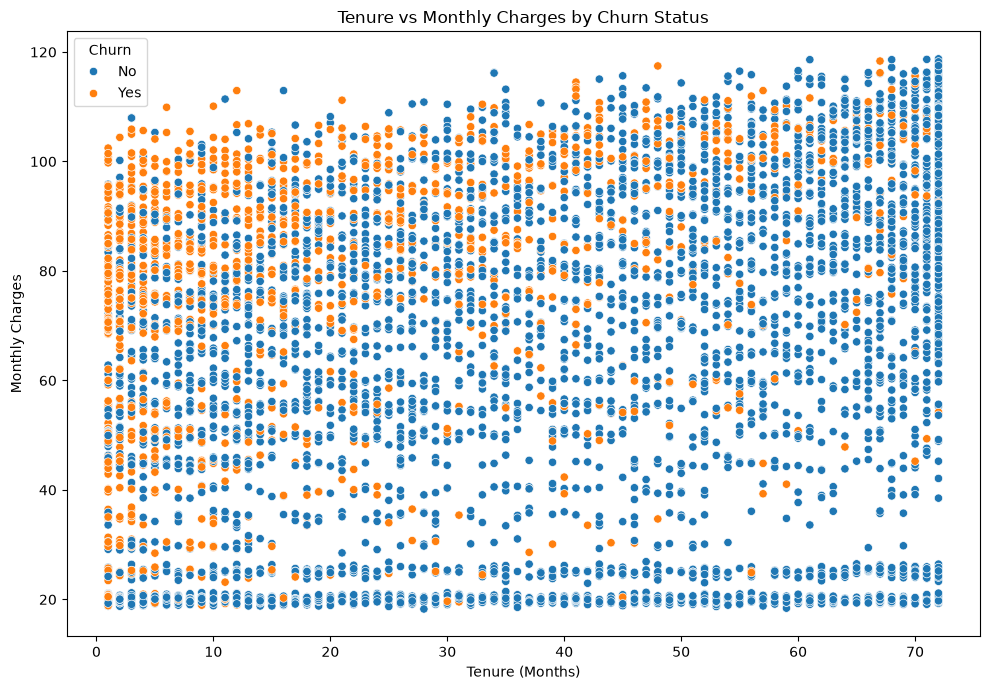

In [41]:
# Cell 41 — Tenure vs Monthly Charges Scatter Plot

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Tenure vs Monthly Charges by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

In [42]:
# Cell 42 — Estimated Monthly Revenue Lost from Churn

churned_df = df[
    df["Churn"] == "Yes"
].copy()

estimated_monthly_revenue_lost = (
    churned_df["MonthlyCharges"].sum()
)

print(
    "Estimated Monthly Revenue Lost:",
    round(estimated_monthly_revenue_lost, 2)
)

Estimated Monthly Revenue Lost: 139130.85


In [43]:
# Cell 43 — High-Value Churned Revenue Risk

high_value_churned_revenue_loss = (
    high_value_churned[
        "MonthlyCharges"
    ].sum()
)

print(
    "Estimated Monthly Revenue Associated with High-Value Churned Customers:",
    round(high_value_churned_revenue_loss, 2)
)

Estimated Monthly Revenue Associated with High-Value Churned Customers: 57503.75


In [44]:
# Cell 44 — Segment with Largest Number of Churned Customers

segment_churn_counts = (
    df[df["Churn"] == "Yes"]
    .groupby("CustomerSegment")
    .size()
)

largest_churned_segment = (
    segment_churn_counts.idxmax()
)

print(
    "Segment containing the largest number of churned customers:",
    largest_churned_segment
)

print(
    "Number of churned customers:",
    segment_churn_counts.max()
)

Segment containing the largest number of churned customers: Short Tenure + High Value
Number of churned customers: 856


In [45]:
# Cell 45 — Highest-Risk Customer Segment

highest_risk_segment = (
    combined_analysis["Churn_Rate"].idxmax()
)

highest_risk_rate = (
    combined_analysis.loc[
        highest_risk_segment,
        "Churn_Rate"
    ]
)

print(
    "Highest-risk customer segment:",
    highest_risk_segment
)

print(
    "Churn rate:",
    round(highest_risk_rate, 2),
    "%"
)

Highest-risk customer segment: Short Tenure + High Value
Churn rate: 58.11 %


In [46]:
# Cell 46 — High-Value Customer Summary

number_high_value = (
    df["HighValue"] == "High-Value"
).sum()

number_high_value_churned = len(
    high_value_churned
)

print(
    "Number of high-value customers:",
    number_high_value
)

print(
    "Number of high-value customers who churned:",
    number_high_value_churned
)

Number of high-value customers: 1758
Number of high-value customers who churned: 578


In [47]:
# Cell 47 — Overall Key Findings

print("KEY FINDINGS")
print("=" * 60)

print(
    f"Total customers: {len(df)}"
)

print(
    f"Overall churn rate: {overall_churn_rate:.2f}%"
)

print(
    f"Highest tenure churn segment: {highest_tenure_churn}"
)

print(
    f"Highest monthly-charge churn segment: {highest_charge_churn}"
)

print(
    f"Highest churn contract type: {highest_contract_churn}"
)

print(
    f"Highest-risk combined segment: {highest_risk_segment}"
)

print(
    f"High-value threshold: {high_value_threshold:.2f}"
)

print(
    f"High-value customers: {number_high_value}"
)

print(
    f"High-value customers already churned: "
    f"{number_high_value_churned}"
)

print(
    f"Active high-value customers showing risk: "
    f"{risk_count}"
)

print(
    f"Estimated monthly revenue lost: "
    f"{estimated_monthly_revenue_lost:.2f}"
)

print(
    f"High-value churned monthly revenue: "
    f"{high_value_churned_revenue_loss:.2f}"
)

KEY FINDINGS
Total customers: 7032
Overall churn rate: 26.58%
Highest tenure churn segment: New Customers
Highest monthly-charge churn segment: High Charges
Highest churn contract type: Month-to-month
Highest-risk combined segment: Short Tenure + High Value
High-value threshold: 89.86
High-value customers: 1758
High-value customers already churned: 578
Active high-value customers showing risk: 41
Estimated monthly revenue lost: 139130.85
High-value churned monthly revenue: 57503.75


In [48]:
# Cell 48 — Business Recommendations

print("BUSINESS RECOMMENDATIONS")
print("=" * 60)

print(
    "1. Focus retention efforts on the highest-churn customer groups."
)

print(
    "2. Closely monitor month-to-month customers because they "
    "have greater flexibility to leave."
)

print(
    "3. Prioritize high-value customers because their churn "
    "creates greater monthly revenue exposure."
)

print(
    "4. Provide proactive onboarding and engagement for "
    "short-tenure high-value customers."
)

print(
    "5. Consider incentives to encourage month-to-month "
    "high-value customers to adopt longer contracts."
)

print(
    "6. Prioritize active high-value customers showing the "
    "defined risk characteristics for retention campaigns."
)

print(
    "7. Use loyalty benefits and personalized support to "
    "maintain long-term customer relationships."
)

BUSINESS RECOMMENDATIONS
1. Focus retention efforts on the highest-churn customer groups.
2. Closely monitor month-to-month customers because they have greater flexibility to leave.
3. Prioritize high-value customers because their churn creates greater monthly revenue exposure.
4. Provide proactive onboarding and engagement for short-tenure high-value customers.
5. Consider incentives to encourage month-to-month high-value customers to adopt longer contracts.
6. Prioritize active high-value customers showing the defined risk characteristics for retention campaigns.
7. Use loyalty benefits and personalized support to maintain long-term customer relationships.


In [49]:
# Cell 49 — Final Summary

final_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Overall Churn Rate (%)",
        "Highest-Risk Segment",
        "High-Value Threshold",
        "Number of High-Value Customers",
        "High-Value Customers Churned",
        "Active High-Value Customers Showing Risk",
        "Estimated Monthly Revenue Lost",
        "High-Value Churned Monthly Revenue"
    ],
    "Value": [
        len(df),
        round(overall_churn_rate, 2),
        highest_risk_segment,
        round(high_value_threshold, 2),
        number_high_value,
        number_high_value_churned,
        risk_count,
        round(estimated_monthly_revenue_lost, 2),
        round(high_value_churned_revenue_loss, 2)
    ]
})

final_summary

,Metric,Value
0,Total Customers,7032
1,Overall Churn Rate (%),26.58
2,Highest-Risk Segment,Short Tenure + High Value
3,High-Value Threshold,89.86
4,Number of High-Value Customers,1758
5,High-Value Customers Churned,578
6,Active High-Value Customers Showing Risk,41
7,Estimated Monthly Revenue Lost,139130.85
8,High-Value Churned Monthly Revenue,57503.75


In [50]:
# Cell 50 — Save High-Value At-Risk Customer Table

high_value_at_risk_table.to_csv(
    "high_value_at_risk_customers.csv",
    index=False
)

print(
    "High-value at-risk customer table saved successfully."
)

High-value at-risk customer table saved successfully.
